# Heat exchanger results

This notebook plots the heat-exchanger power and the air/coolant outlet temperatures exported from STAR-CCM+.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
DATA_DIR = Path.cwd()
HEAT_FILE = DATA_DIR / 'Heat exchanger.csv'
TEMPERATURE_FILE = DATA_DIR / 'air  and coolant temperature.csv'


In [12]:
heat = pd.read_csv(HEAT_FILE)
temperature = pd.read_csv(TEMPERATURE_FILE)

# data are inverted in head exchanger 


heat.columns = ['Iteration', 'Heat_transfer_W']
temperature.columns = [
    'Air_iteration', 'Air_temperature_K',
    'Coolant_iteration', 'Coolant_temperature_K',
]

heat['Heat_transfer_W'] = heat['Heat_transfer_W'].abs()

display(heat.head())
display(temperature.head())

,Iteration,Heat_transfer_W
0,1.0,0.000000
1,2.0,211.094294
2,3.0,758.624620
3,4.0,1158.162287
4,5.0,862.707812


,Air_iteration,Air_temperature_K,Coolant_iteration,Coolant_temperature_K
0,1.0,300.000000,1.0,300.000000
1,2.0,300.000191,2.0,300.187377
2,3.0,300.001803,3.0,300.808709
3,4.0,300.002102,4.0,301.883076
4,5.0,300.005669,5.0,303.867306


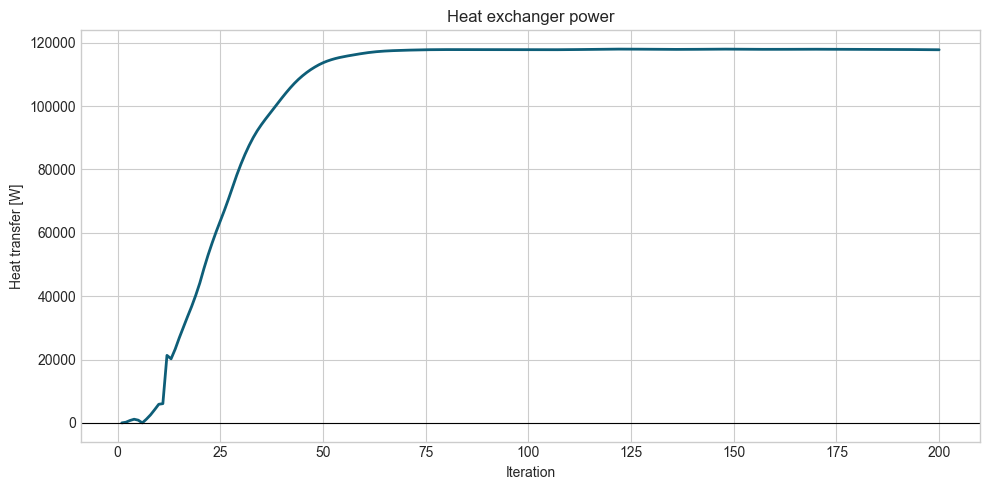

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(heat['Iteration'], heat['Heat_transfer_W'], color='#0e5e78', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set(title='Heat exchanger power', xlabel='Iteration', ylabel='Heat transfer [W]')
fig.tight_layout()
plt.show()

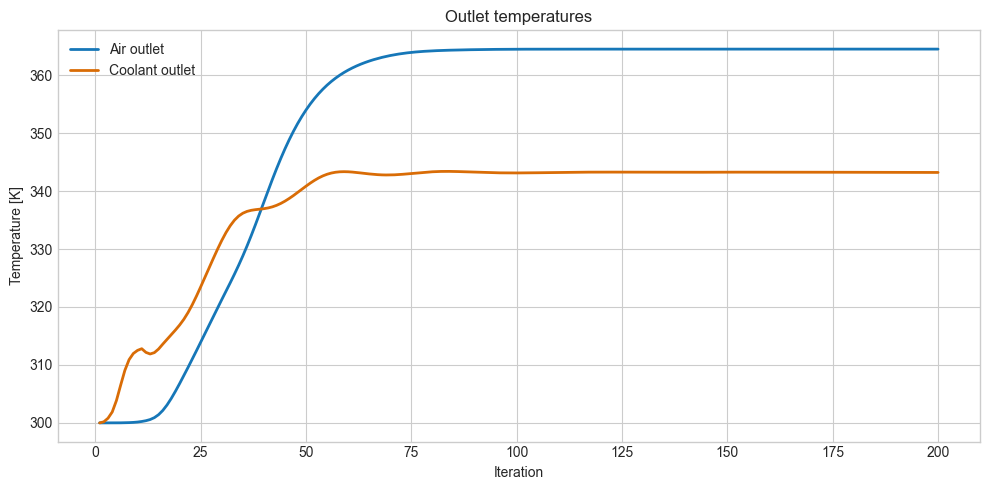

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temperature['Air_iteration'], temperature['Air_temperature_K'], label='Air outlet', color='#1677b8', linewidth=2)
ax.plot(temperature['Coolant_iteration'], temperature['Coolant_temperature_K'], label='Coolant outlet', color='#d96c06', linewidth=2)
ax.set(title='Outlet temperatures', xlabel='Iteration', ylabel='Temperature [K]')
ax.legend()
fig.tight_layout()
plt.show()

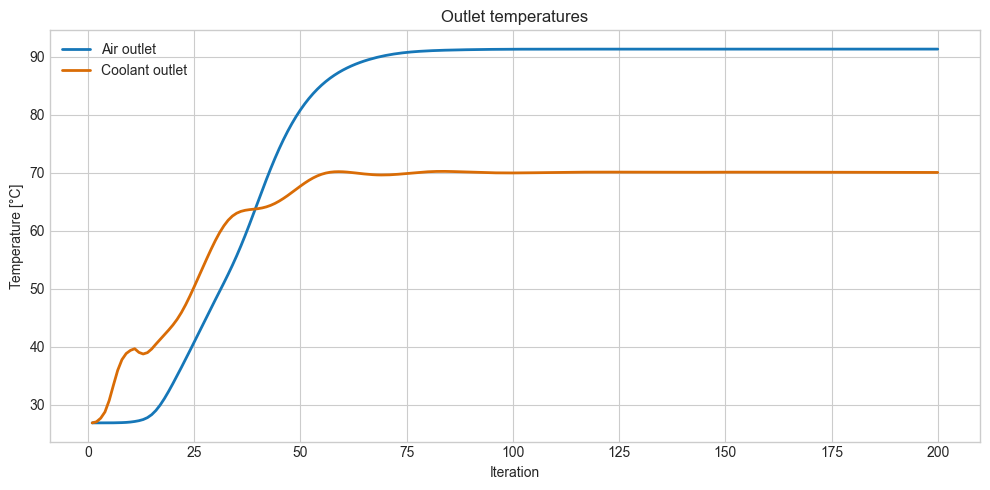

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temperature['Air_iteration'], temperature['Air_temperature_K'] - 273.15, label='Air outlet', color='#1677b8', linewidth=2)
ax.plot(temperature['Coolant_iteration'], temperature['Coolant_temperature_K'] - 273.15, label='Coolant outlet', color='#d96c06', linewidth=2)
ax.set(title='Outlet temperatures', xlabel='Iteration', ylabel='Temperature [°C]')
ax.legend()
fig.tight_layout()
plt.show()